In [44]:
# Cell 1 — Install & Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d2e',
    'axes.edgecolor': '#3a3d50',   'text.color': '#e0e0e0',
    'axes.labelcolor': '#e0e0e0',  'xtick.color': '#b0b0b0',
    'ytick.color': '#b0b0b0',      'grid.color': '#2a2d3e',
    'grid.alpha': 0.5,             'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,          'axes.labelsize': 11,
})
PALETTE = ['#6c63ff','#ff6584','#43e97b','#f7971e',
           '#12c2e9','#f64f59','#c471ed','#f7ce68']
sns.set_palette(PALETTE)
print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [45]:
import zipfile
import os
import pandas as pd # Ensure pandas is imported if not already

zip_file_path = r"dataset.zip"
extract_to_dir = r"extracted_dataset"

# Create the directory if it doesn't exist
os.makedirs(extract_to_dir, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_dir)

# The original code was looking for 'dataset.xlsx', but the extracted files are CSVs.
# Based on the available files, let's try reading 'players.csv' as an example.
# You can change 'players.csv' to 'deliveries.csv', 'seasons.csv', or 'matches.csv'
# depending on which dataset you intend to load.
csv_file_path = os.path.join(extract_to_dir, 'players.csv')

# Use pd.read_csv to read the CSV file
df = pd.read_csv(csv_file_path)

print(f"Successfully loaded {os.path.basename(csv_file_path)} into DataFrame df.")
print(df.head())

Successfully loaded players.csv into DataFrame df.
  player_id      player_name   nationality  dob_year   batting_style  \
0     P0001    Umesh Cummins         India      1981  Right-hand bat   
1     P0002  Jofra Natarajan  South Africa      1991  Right-hand bat   
2     P0003    Aaron Buttler         India      2002  Right-hand bat   
3     P0004     Shadab Finch     Australia      1990  Right-hand bat   
4     P0005     Reece Ashraf  South Africa      2002   Left-hand bat   

            bowling_style playing_role  ipl_debut_season  last_season_played  \
0                     NaN      Batsman              2008                2018   
1  Slow left-arm orthodox       Bowler              2011                2019   
2           Left-arm fast  All-Rounder              2024                2025   
3                     NaN      Batsman              2008                2017   
4          Right-arm fast       Bowler              2023                2025   

   is_capped_international  base_pr

In [46]:

with zipfile.ZipFile('dataset.zip', 'r') as z:
    z.extractall('dataset')

matches    = pd.read_csv('dataset/matches.csv')
deliveries = pd.read_csv('dataset/deliveries.csv')
players    = pd.read_csv('dataset/players.csv')
seasons    = pd.read_csv('dataset/seasons.csv')

for name, df in [("matches", matches), ("deliveries", deliveries),
                  ("players", players), ("seasons", seasons)]:
    print(f"  {name:12s}: {df.shape[0]:,} rows × {df.shape[1]} cols")

  matches     : 1,158 rows × 25 cols
  deliveries  : 134,190 rows × 18 cols
  players     : 580 rows × 12 cols
  seasons     : 18 rows × 14 cols


In [47]:
# Cell 3 — EDA: Overview & Missing Values
print("=== MATCHES — First 3 Rows ===")
display(matches.head(3))

print("\n=== MISSING VALUES ===")
print(matches.isnull().sum()[matches.isnull().sum() > 0])

print("\n=== DATA TYPES ===")
print(matches.dtypes)

=== MATCHES — First 3 Rows ===


,match_id,season,match_number,stage,date,venue,city,team1,team2,toss_winner,...,second_innings_wickets,second_innings_overs,result,winner,win_by,win_margin,player_of_match,umpire1,umpire2,is_day_night
0,M0001,2008,1,League,2008-03-13,Punjab Cricket Association Stadium,Mohali,Kings XI Punjab,Royal Challengers Bangalore,Royal Challengers Bangalore,...,8,15.4,normal,Kings XI Punjab,runs,81,Moeen Taylor,Aleem Dar,Marais Erasmus,False
1,M0002,2008,2,League,2008-03-14,Greenfield Intl Stadium,Thiruvananthapuram,Mumbai Indians,Kolkata Knight Riders,Mumbai Indians,...,3,18.6,normal,Kolkata Knight Riders,wickets,7,Shai Amla,Michael Gough,Simon Taufel,True
2,M0003,2008,3,League,2008-03-15,M. A. Chidambaram Stadium,Chennai,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,...,2,19.0,normal,Chennai Super Kings,runs,81,Lungi Warner,KN Ananthapadmanabhan,Michael Gough,True



=== MISSING VALUES ===
winner    26
win_by    26
dtype: int64

=== DATA TYPES ===
match_id                      str
season                      int64
match_number                int64
stage                         str
date                          str
venue                         str
city                          str
team1                         str
team2                         str
toss_winner                   str
toss_decision                 str
first_innings_score         int64
first_innings_wickets       int64
first_innings_overs       float64
second_innings_score        int64
second_innings_wickets      int64
second_innings_overs      float64
result                        str
winner                        str
win_by                        str
win_margin                  int64
player_of_match               str
umpire1                       str
umpire2                       str
is_day_night                 bool
dtype: object


In [48]:
# Cell 4 — Descriptive Statistics
print("=== DESCRIPTIVE STATISTICS ===")
display(matches[['first_innings_score', 'second_innings_score',
                  'first_innings_wickets', 'win_margin']].describe().round(2))

print("\n=== DELIVERIES STATS ===")
display(deliveries[['batsman_runs', 'extra_runs',
                     'total_runs', 'is_wicket']].describe().round(2))

=== DESCRIPTIVE STATISTICS ===


,first_innings_score,second_innings_score,first_innings_wickets,win_margin
count,1158.00,1158.00,1158.00,1158.00
mean,175.10,155.80,5.90,22.26
std,47.48,51.89,2.62,25.55
min,51.00,0.00,1.00,0.00
25%,135.00,121.00,4.00,4.00
50%,176.00,157.00,6.00,8.00
75%,211.00,197.00,8.00,39.00
max,315.00,244.00,10.00,85.00



=== DELIVERIES STATS ===


,batsman_runs,extra_runs,total_runs
count,134190.00,134190.00,134190.00
mean,2.20,0.13,2.34
std,1.85,0.54,1.94
min,0.00,0.00,0.00
25%,1.00,0.00,1.00
50%,2.00,0.00,2.00
75%,4.00,0.00,4.00
max,6.00,4.00,10.00


In [49]:
# Cell 5 — Feature Engineering
matches['date']         = pd.to_datetime(matches['date'])
matches['run_diff']     = matches['first_innings_score'] - matches['second_innings_score']
matches['high_scoring'] = (matches['first_innings_score'] >= 180).astype(int)

deliveries['is_boundary'] = deliveries['batsman_runs'].isin([4, 6]).astype(int)
deliveries['is_six']      = (deliveries['batsman_runs'] == 6).astype(int)
deliveries['is_four']     = (deliveries['batsman_runs'] == 4).astype(int)

print("✅ New features created:")
print("  matches    → run_diff, high_scoring")
print("  deliveries → is_boundary, is_six, is_four")
print(f"\n  High-scoring matches (≥180): {matches['high_scoring'].sum()}")
print(f"  Total boundaries:            {deliveries['is_boundary'].sum():,}")

✅ New features created:
  matches    → run_diff, high_scoring
  deliveries → is_boundary, is_six, is_four

  High-scoring matches (≥180): 553
  Total boundaries:            42,105


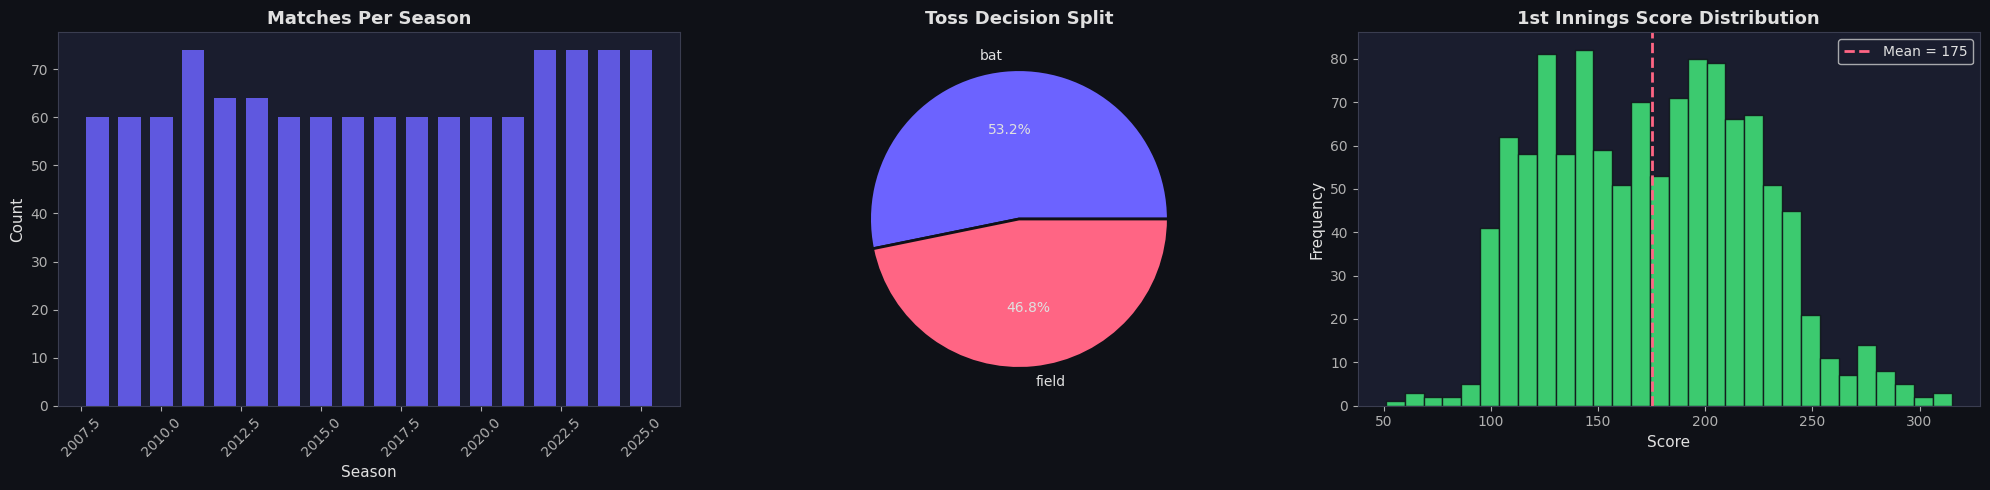

In [50]:
# Cell 6 — Season & Toss Analysis
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.patch.set_facecolor('#0f1117')
for ax in axes:
    ax.set_facecolor('#1a1d2e')

# Matches per season
season_counts = matches.groupby('season').size().reset_index(name='matches')
bars = axes[0].bar(season_counts['season'], season_counts['matches'],
                   color=PALETTE[0], alpha=0.85, width=0.7)
axes[0].set_title('Matches Per Season', fontweight='bold')
axes[0].set_xlabel('Season'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Toss decision pie
td = matches['toss_decision'].value_counts()
axes[1].pie(td.values, labels=td.index, autopct='%1.1f%%',
            colors=PALETTE[:2], wedgeprops={'edgecolor': '#0f1117', 'linewidth': 2})
axes[1].set_title('Toss Decision Split', fontweight='bold')

# 1st innings score histogram
axes[2].hist(matches['first_innings_score'].dropna(), bins=30,
             color=PALETTE[2], edgecolor='#0f1117', alpha=0.85)
axes[2].axvline(matches['first_innings_score'].mean(), color=PALETTE[1],
                lw=2, linestyle='--',
                label=f"Mean = {matches['first_innings_score'].mean():.0f}")
axes[2].set_title('1st Innings Score Distribution', fontweight='bold')
axes[2].set_xlabel('Score'); axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.tight_layout()
plt.show()

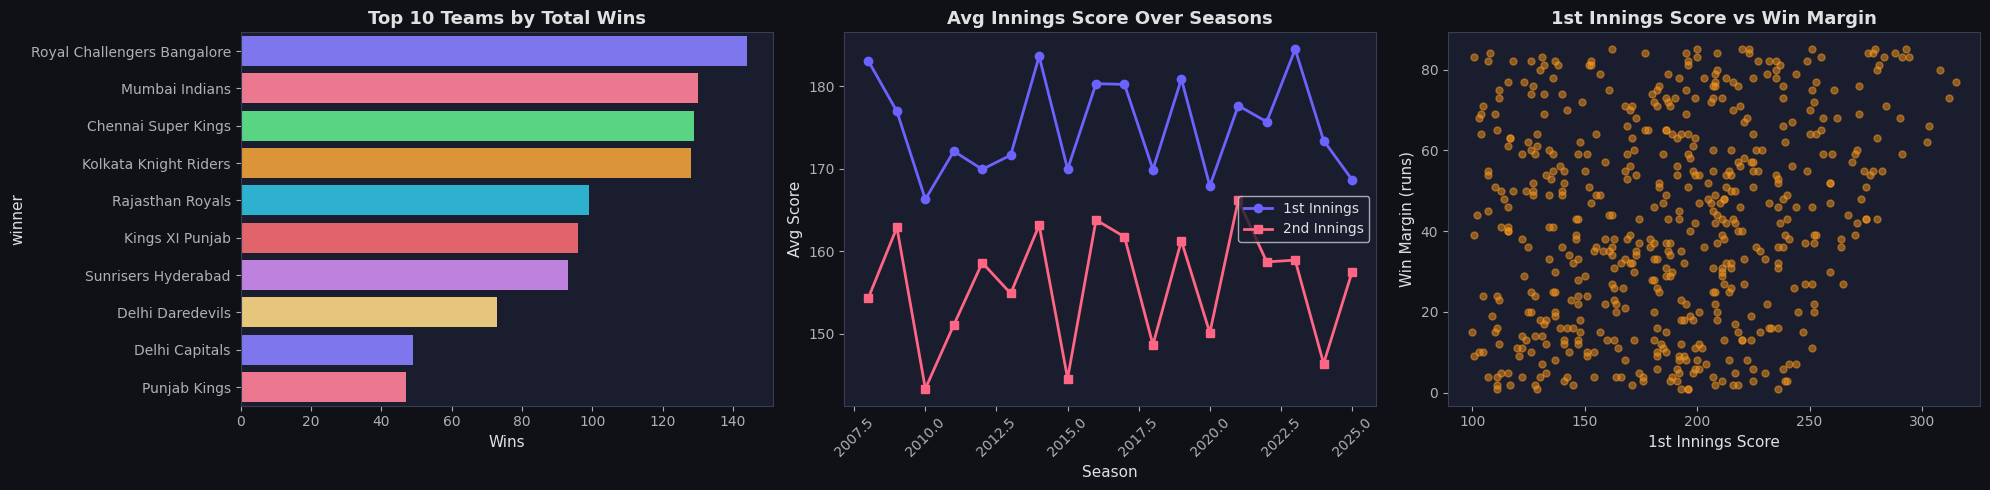

In [51]:
# Cell 7 — Team Performance & Score Trends
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.patch.set_facecolor('#0f1117')
for ax in axes:
    ax.set_facecolor('#1a1d2e')

# Top 10 teams by wins
team_wins = matches['winner'].value_counts().head(10)
sns.barplot(x=team_wins.values, y=team_wins.index, ax=axes[0], palette=PALETTE)
axes[0].set_title('Top 10 Teams by Total Wins', fontweight='bold')
axes[0].set_xlabel('Wins')

# Avg innings scores by season
avg_scores = matches.groupby('season')[['first_innings_score',
                                         'second_innings_score']].mean()
axes[1].plot(avg_scores.index, avg_scores['first_innings_score'],
             marker='o', color=PALETTE[0], label='1st Innings', lw=2)
axes[1].plot(avg_scores.index, avg_scores['second_innings_score'],
             marker='s', color=PALETTE[1], label='2nd Innings', lw=2)
axes[1].set_title('Avg Innings Score Over Seasons', fontweight='bold')
axes[1].set_xlabel('Season'); axes[1].set_ylabel('Avg Score')
axes[1].legend(); axes[1].tick_params(axis='x', rotation=45)

# Scatter: 1st innings score vs win margin
runs_wins = matches[matches['win_by'] == 'runs'].dropna(subset=['win_margin'])
axes[2].scatter(runs_wins['first_innings_score'], runs_wins['win_margin'],
                alpha=0.5, color=PALETTE[3], s=25)
axes[2].set_title('1st Innings Score vs Win Margin', fontweight='bold')
axes[2].set_xlabel('1st Innings Score'); axes[2].set_ylabel('Win Margin (runs)')

plt.tight_layout()
plt.show()

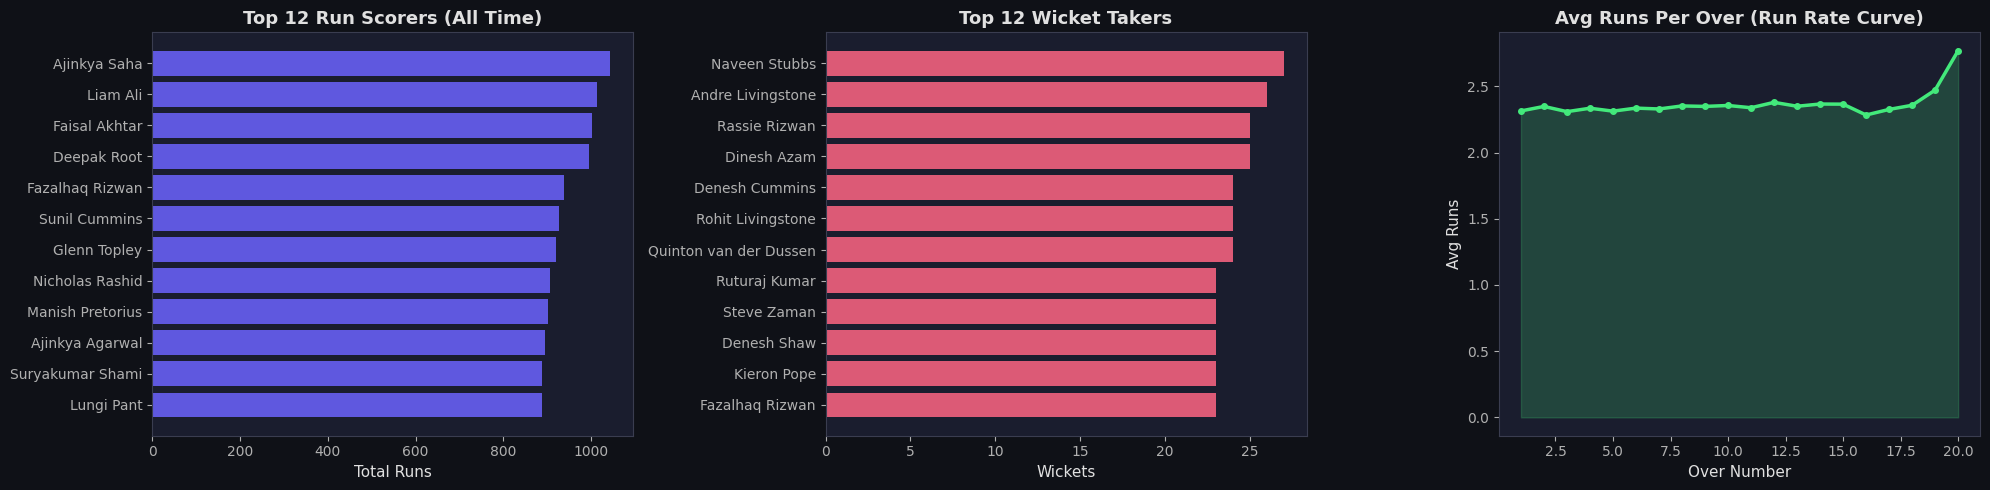

In [52]:
# Cell 8 — Batting & Bowling Analysis
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.patch.set_facecolor('#0f1117')
for ax in axes:
    ax.set_facecolor('#1a1d2e')

# Top run scorers
top_batters = (deliveries.groupby('striker')['batsman_runs']
               .sum().sort_values(ascending=False).head(12))
axes[0].barh(top_batters.index[::-1], top_batters.values[::-1],
             color=PALETTE[0], alpha=0.85)
axes[0].set_title('Top 12 Run Scorers (All Time)', fontweight='bold')
axes[0].set_xlabel('Total Runs')

# Top wicket takers
wkts = (deliveries[deliveries['is_wicket']]
        .groupby('bowler')['is_wicket'].count()
        .sort_values(ascending=False).head(12))
axes[1].barh(wkts.index[::-1], wkts.values[::-1],
             color=PALETTE[1], alpha=0.85)
axes[1].set_title('Top 12 Wicket Takers', fontweight='bold')
axes[1].set_xlabel('Wickets')

# Run rate curve by over
over_runs = deliveries.groupby('over')['total_runs'].mean()
axes[2].plot(over_runs.index, over_runs.values,
             color=PALETTE[2], lw=2.5, marker='o', markersize=4)
axes[2].fill_between(over_runs.index, over_runs.values, alpha=0.2, color=PALETTE[2])
axes[2].set_title('Avg Runs Per Over (Run Rate Curve)', fontweight='bold')
axes[2].set_xlabel('Over Number'); axes[2].set_ylabel('Avg Runs')

plt.tight_layout()
plt.show()

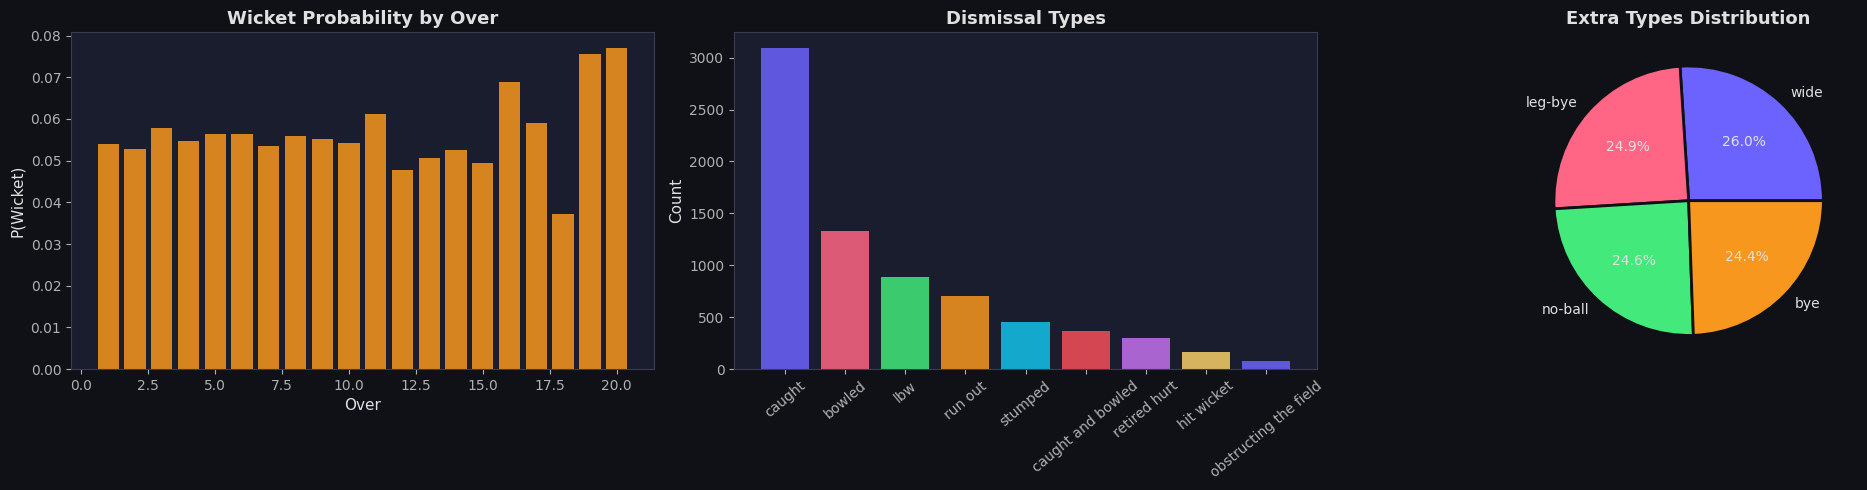

In [53]:
# Cell 9 — Wickets, Dismissals & Extras
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.patch.set_facecolor('#0f1117')
for ax in axes:
    ax.set_facecolor('#1a1d2e')

# Wicket probability by over
wkt_over = deliveries.groupby('over')['is_wicket'].mean()
axes[0].bar(wkt_over.index, wkt_over.values, color=PALETTE[3], alpha=0.85)
axes[0].set_title('Wicket Probability by Over', fontweight='bold')
axes[0].set_xlabel('Over'); axes[0].set_ylabel('P(Wicket)')

# Dismissal types
dm = deliveries[deliveries['is_wicket']]['dismissal_type'].value_counts()
axes[1].bar(dm.index, dm.values, color=PALETTE[:len(dm)], alpha=0.85)
axes[1].set_title('Dismissal Types', fontweight='bold')
axes[1].tick_params(axis='x', rotation=40)
axes[1].set_ylabel('Count')

# Extra types pie
ex = deliveries[deliveries['extra_type'].notna()]['extra_type'].value_counts()
axes[2].pie(ex.values, labels=ex.index, autopct='%1.1f%%',
            colors=PALETTE[:len(ex)],
            wedgeprops={'edgecolor': '#0f1117', 'linewidth': 2})
axes[2].set_title('Extra Types Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

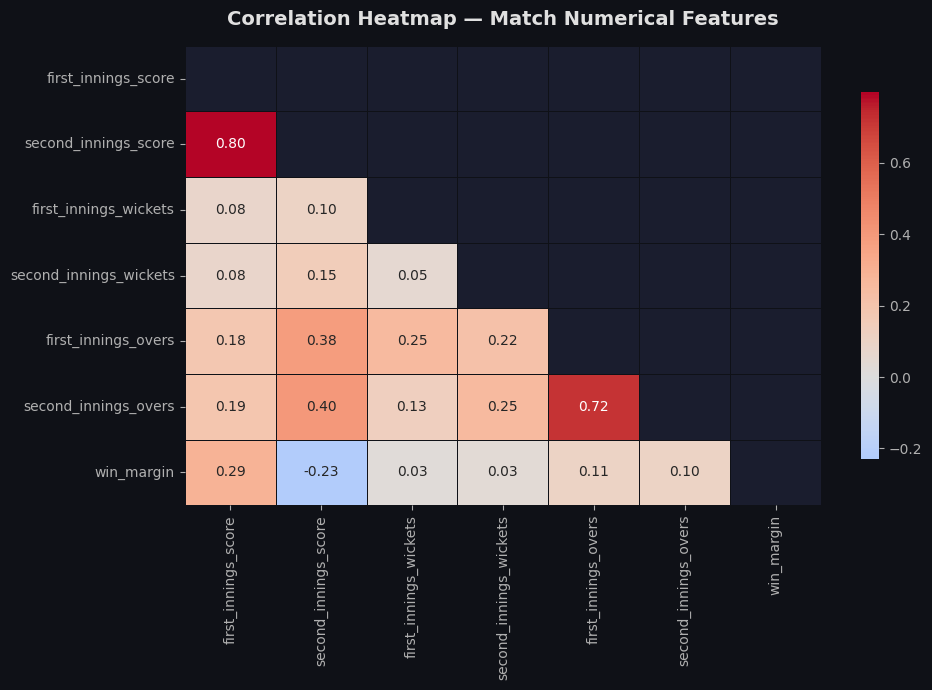

In [54]:
# Cell 10 — Correlation Heatmap
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

num_cols = ['first_innings_score', 'second_innings_score',
            'first_innings_wickets', 'second_innings_wickets',
            'first_innings_overs', 'second_innings_overs', 'win_margin']
corr = matches[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, linecolor='#0f1117',
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — Match Numerical Features',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [55]:
# Cell 11 — H1: Independent t-test
bat_first   = matches.loc[matches['toss_decision'] == 'bat',   'first_innings_score'].dropna()
field_first = matches.loc[matches['toss_decision'] == 'field', 'second_innings_score'].dropna()

t1, p1 = stats.ttest_ind(bat_first, field_first)

print("H₀: Mean bat-first score = Mean chasing score")
print("H₁: They are significantly different")
print("─" * 45)
print(f"Mean bat-first  : {bat_first.mean():.2f}")
print(f"Mean chasing    : {field_first.mean():.2f}")
print(f"T-statistic     : {t1:.4f}")
print(f"p-value         : {p1:.6f}")
print("─" * 45)
print(f"Result → {'✅ REJECT H₀ — Significant difference (p < 0.05)' if p1 < 0.05 else '❌ FAIL to reject H₀'}")

H₀: Mean bat-first score = Mean chasing score
H₁: They are significantly different
─────────────────────────────────────────────
Mean bat-first  : 175.47
Mean chasing    : 156.48
T-statistic     : 6.5032
p-value         : 0.000000
─────────────────────────────────────────────
Result → ✅ REJECT H₀ — Significant difference (p < 0.05)


In [56]:
# Cell 12 — H2: Chi-Square Test
hs_bat_wins = len(matches[(matches['high_scoring'] == 1) &
                           (matches['toss_decision'] == 'bat') &
                           (matches['winner'] == matches['toss_winner'])])
ls_bat_wins = len(matches[(matches['high_scoring'] == 0) &
                           (matches['toss_decision'] == 'bat') &
                           (matches['winner'] == matches['toss_winner'])])
total_hs = matches[matches['high_scoring'] == 1].shape[0]
total_ls = matches[matches['high_scoring'] == 0].shape[0]

contingency = np.array([[hs_bat_wins, total_hs - hs_bat_wins],
                         [ls_bat_wins, total_ls - ls_bat_wins]])
chi2, p2, dof, expected = stats.chi2_contingency(contingency)

print("Contingency Table:")
display(pd.DataFrame(contingency,
        index=['High-Scoring (≥180)', 'Low-Scoring (<180)'],
        columns=['Bat-Team Won', 'Bat-Team Lost']))
print(f"\nχ²  = {chi2:.4f}")
print(f"p   = {p2:.4f}")
print(f"df  = {dof}")
print(f"\nResult → {'✅ REJECT H₀ — Association exists' if p2 < 0.05 else '❌ FAIL to reject H₀'}")

Contingency Table:


,Bat-Team Won,Bat-Team Lost
High-Scoring (≥180),157,396
Low-Scoring (<180),135,470



χ²  = 5.3396
p   = 0.0208
df  = 1

Result → ✅ REJECT H₀ — Association exists


In [57]:
# Cell 13 — H3, H4, H5
day   = matches[matches['is_day_night'] == False]['first_innings_score'].dropna()
night = matches[matches['is_day_night'] == True ]['first_innings_score'].dropna()

# H3 — Day vs Day-Night (t-test)
t3, p3 = stats.ttest_ind(day, night)
print("[H3] Day vs Day-Night — 1st Innings Score")
print(f"  Mean Day        = {day.mean():.2f}")
print(f"  Mean Day-Night  = {night.mean():.2f}")
print(f"  t = {t3:.4f},  p = {p3:.4f}")
print(f"  → {'✅ REJECT H₀' if p3 < 0.05 else '❌ FAIL to reject H₀ — No significant difference'}\n")

# H4 — Shapiro-Wilk Normality
stat4, p4 = stats.shapiro(matches['first_innings_score'].dropna().sample(100, random_state=42))
print("[H4] Shapiro-Wilk Normality Test")
print(f"  W = {stat4:.4f},  p = {p4:.4f}")
print(f"  → {'Not normally distributed' if p4 < 0.05 else 'Normally distributed'}\n")

# H5 — Mann-Whitney U
u_stat, p_mw = stats.mannwhitneyu(bat_first, field_first, alternative='two-sided')
print("[H5] Mann-Whitney U (non-parametric)")
print(f"  U = {u_stat:.2f},  p = {p_mw:.6f}")
print(f"  → {'✅ REJECT H₀ — Confirms H1 non-parametrically' if p_mw < 0.05 else '❌ FAIL to reject H₀'}")

[H3] Day vs Day-Night — 1st Innings Score
  Mean Day        = 175.30
  Mean Day-Night  = 174.96
  t = 0.1206,  p = 0.9040
  → ❌ FAIL to reject H₀ — No significant difference

[H4] Shapiro-Wilk Normality Test
  W = 0.9706,  p = 0.0247
  → Not normally distributed

[H5] Mann-Whitney U (non-parametric)
  U = 197407.50,  p = 0.000000
  → ✅ REJECT H₀ — Confirms H1 non-parametrically


In [58]:
# Cell 13 — H3, H4, H5
day   = matches[matches['is_day_night'] == False]['first_innings_score'].dropna()
night = matches[matches['is_day_night'] == True ]['first_innings_score'].dropna()

# H3 — Day vs Day-Night (t-test)
t3, p3 = stats.ttest_ind(day, night)
print("[H3] Day vs Day-Night — 1st Innings Score")
print(f"  Mean Day        = {day.mean():.2f}")
print(f"  Mean Day-Night  = {night.mean():.2f}")
print(f"  t = {t3:.4f},  p = {p3:.4f}")
print(f"  → {'✅ REJECT H₀' if p3 < 0.05 else '❌ FAIL to reject H₀ — No significant difference'}\n")

# H4 — Shapiro-Wilk Normality
stat4, p4 = stats.shapiro(matches['first_innings_score'].dropna().sample(100, random_state=42))
print("[H4] Shapiro-Wilk Normality Test")
print(f"  W = {stat4:.4f},  p = {p4:.4f}")
print(f"  → {'Not normally distributed' if p4 < 0.05 else 'Normally distributed'}\n")

# H5 — Mann-Whitney U
u_stat, p_mw = stats.mannwhitneyu(bat_first, field_first, alternative='two-sided')
print("[H5] Mann-Whitney U (non-parametric)")
print(f"  U = {u_stat:.2f},  p = {p_mw:.6f}")
print(f"  → {'✅ REJECT H₀ — Confirms H1 non-parametrically' if p_mw < 0.05 else '❌ FAIL to reject H₀'}")

[H3] Day vs Day-Night — 1st Innings Score
  Mean Day        = 175.30
  Mean Day-Night  = 174.96
  t = 0.1206,  p = 0.9040
  → ❌ FAIL to reject H₀ — No significant difference

[H4] Shapiro-Wilk Normality Test
  W = 0.9706,  p = 0.0247
  → Not normally distributed

[H5] Mann-Whitney U (non-parametric)
  U = 197407.50,  p = 0.000000
  → ✅ REJECT H₀ — Confirms H1 non-parametrically


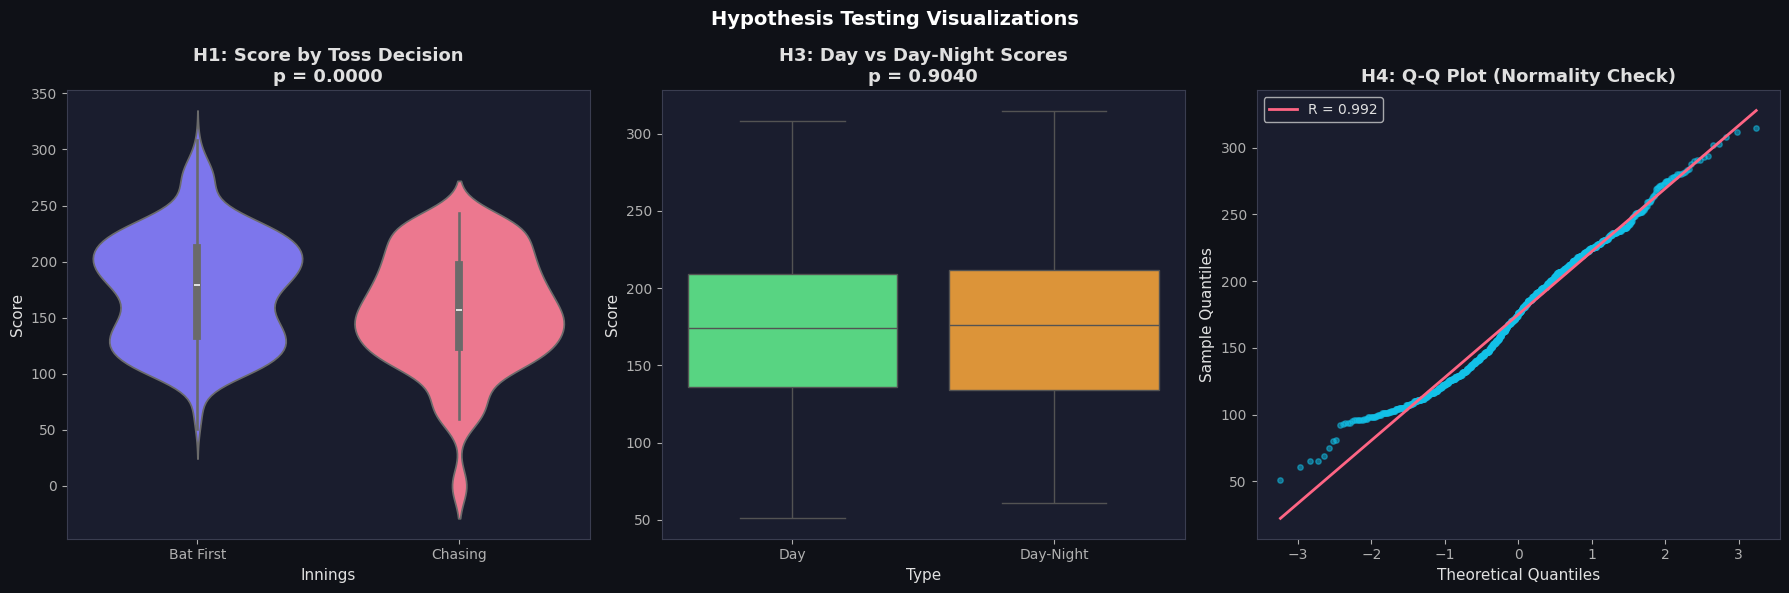

In [59]:
# Cell 14 — Hypothesis Testing Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0f1117')
for ax in axes:
    ax.set_facecolor('#1a1d2e')

# H1 — Violin plot
data_vio = pd.DataFrame({'Bat First': bat_first,
                          'Chasing': field_first}).melt(var_name='Innings', value_name='Score')
sns.violinplot(data=data_vio, x='Innings', y='Score',
               palette=[PALETTE[0], PALETTE[1]], ax=axes[0])
axes[0].set_title(f'H1: Score by Toss Decision\np = {p1:.4f}', fontweight='bold')

# H3 — Box plot
data_dn = pd.DataFrame({'Day': day, 'Day-Night': night}).melt(
    var_name='Type', value_name='Score')
sns.boxplot(data=data_dn, x='Type', y='Score',
            palette=[PALETTE[2], PALETTE[3]], ax=axes[1])
axes[1].set_title(f'H3: Day vs Day-Night Scores\np = {p3:.4f}', fontweight='bold')

# H4 — Q-Q Plot
(osm, osr), (slope, intercept, r) = stats.probplot(
    matches['first_innings_score'].dropna(), dist='norm')
axes[2].scatter(osm, osr, alpha=0.5, s=15, color=PALETTE[4])
x_line = np.linspace(min(osm), max(osm), 100)
axes[2].plot(x_line, slope * x_line + intercept,
             color=PALETTE[1], lw=2, label=f'R = {r:.3f}')
axes[2].set_title('H4: Q-Q Plot (Normality Check)', fontweight='bold')
axes[2].set_xlabel('Theoretical Quantiles')
axes[2].set_ylabel('Sample Quantiles')
axes[2].legend()

plt.suptitle('Hypothesis Testing Visualizations',
             fontsize=14, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

In [60]:
# Cell 15 — Simple Linear Regression
reg_data = matches[['first_innings_score', 'second_innings_score',
                     'first_innings_wickets', 'win_margin']].dropna()

X1 = reg_data[['first_innings_score']].values
y1 = reg_data['second_innings_score'].values

X1_tr, X1_te, y1_tr, y1_te = train_test_split(X1, y1, test_size=0.2, random_state=42)

lr1 = LinearRegression()
lr1.fit(X1_tr, y1_tr)
y1_pred = lr1.predict(X1_te)

r_p, p_p = stats.pearsonr(reg_data['first_innings_score'],
                            reg_data['second_innings_score'])

print("Model 1 — 2nd Innings Score ~ 1st Innings Score")
print("─" * 50)
print(f"Equation   :  2nd_score = {lr1.coef_[0]:.4f} × 1st_score + {lr1.intercept_:.4f}")
print(f"R² (test)  :  {r2_score(y1_te, y1_pred):.4f}")
print(f"RMSE       :  {np.sqrt(mean_squared_error(y1_te, y1_pred)):.4f}")
print(f"Pearson r  :  {r_p:.4f}  (p = {p_p:.2e})")

Model 1 — 2nd Innings Score ~ 1st Innings Score
──────────────────────────────────────────────────
Equation   :  2nd_score = 0.8830 × 1st_score + 1.1613
R² (test)  :  0.6559
RMSE       :  28.8159
Pearson r  :  0.7994  (p = 4.88e-258)


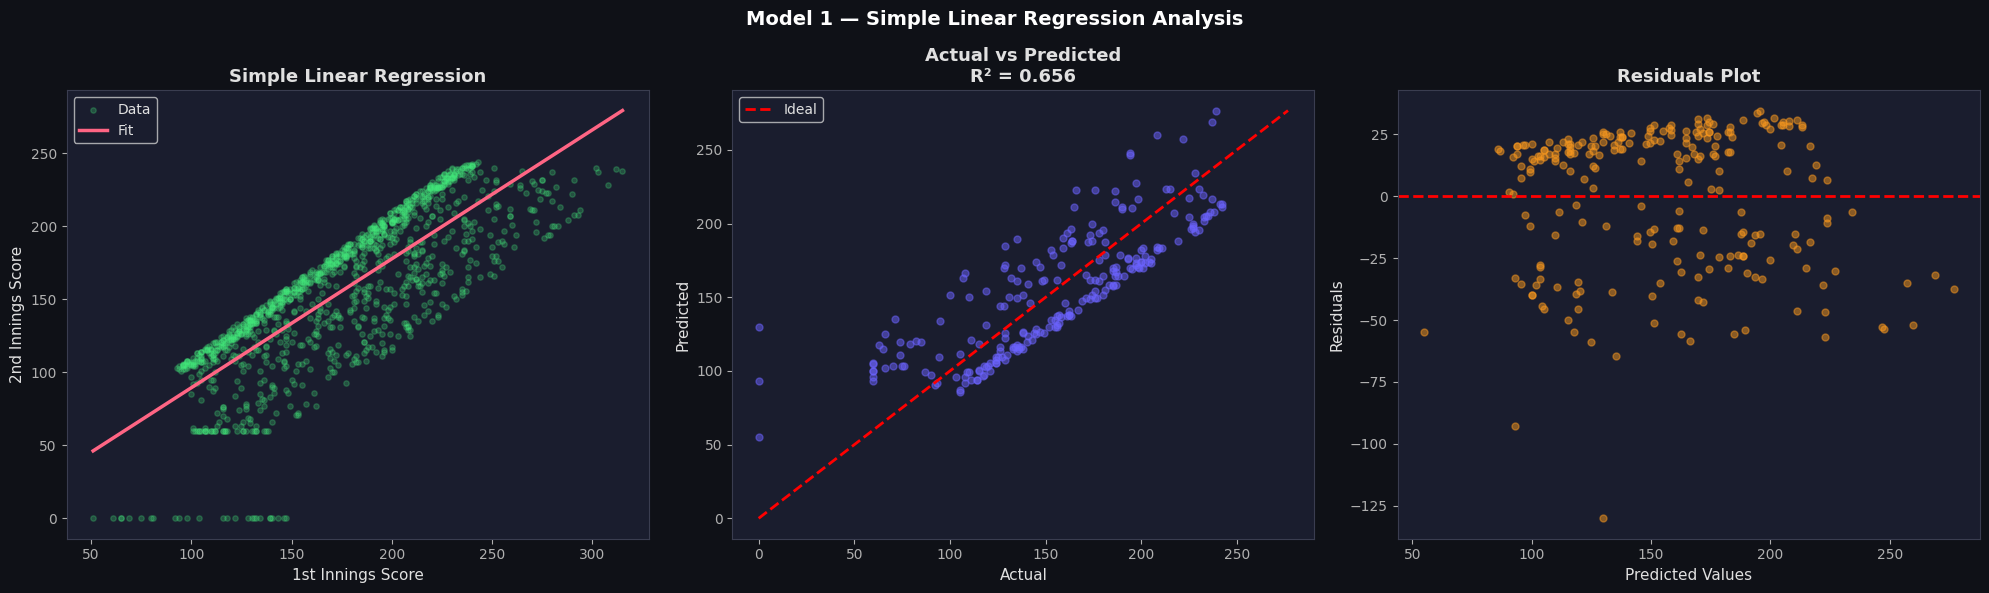

In [61]:
# Cell 16 — Model 1 Regression Plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('#0f1117')
for ax in axes:
    ax.set_facecolor('#1a1d2e')

# Scatter + regression line
x_range = np.linspace(X1.min(), X1.max(), 200).reshape(-1, 1)
axes[0].scatter(X1, y1, alpha=0.25, color=PALETTE[2], s=15, label='Data')
axes[0].plot(x_range, lr1.predict(x_range), color=PALETTE[1], lw=2.5, label='Fit')
axes[0].set_title('Simple Linear Regression', fontweight='bold')
axes[0].set_xlabel('1st Innings Score')
axes[0].set_ylabel('2nd Innings Score')
axes[0].legend()

# Actual vs Predicted
axes[1].scatter(y1_te, y1_pred, alpha=0.5, color=PALETTE[0], s=25)
mn, mx = min(y1_te.min(), y1_pred.min()), max(y1_te.max(), y1_pred.max())
axes[1].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Ideal')
axes[1].set_title(f'Actual vs Predicted\nR² = {r2_score(y1_te, y1_pred):.3f}', fontweight='bold')
axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted')
axes[1].legend()

# Residuals
residuals = y1_te - y1_pred
axes[2].scatter(y1_pred, residuals, alpha=0.5, color=PALETTE[3], s=25)
axes[2].axhline(0, color='red', lw=2, linestyle='--')
axes[2].set_title('Residuals Plot', fontweight='bold')
axes[2].set_xlabel('Predicted Values')
axes[2].set_ylabel('Residuals')

plt.suptitle('Model 1 — Simple Linear Regression Analysis',
             fontsize=14, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

In [62]:
# Cell 17 — Multiple Linear Regression
feat_cols = ['first_innings_score', 'second_innings_score',
             'first_innings_wickets', 'second_innings_wickets']

reg2 = matches[feat_cols + ['win_margin']].dropna()
X2 = reg2[feat_cols].values
y2 = reg2['win_margin'].values

scaler = StandardScaler()
X2_sc = scaler.fit_transform(X2)

X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2_sc, y2, test_size=0.2, random_state=42)

lr2 = LinearRegression()
lr2.fit(X2_tr, y2_tr)
y2_pred = lr2.predict(X2_te)

print("Model 2 — Win Margin ~ Multiple Features")
print("─" * 50)
for f, c in zip(feat_cols, lr2.coef_):
    print(f"  {f:30s}: {c:+.4f}")
print(f"\nR² (test)  :  {r2_score(y2_te, y2_pred):.4f}")
print(f"RMSE       :  {np.sqrt(mean_squared_error(y2_te, y2_pred)):.4f}")

Model 2 — Win Margin ~ Multiple Features
──────────────────────────────────────────────────
  first_innings_score           : +33.5872
  second_innings_score          : -32.7642
  first_innings_wickets         : +1.3350
  second_innings_wickets        : +3.2957

R² (test)  :  0.7474
RMSE       :  12.6863


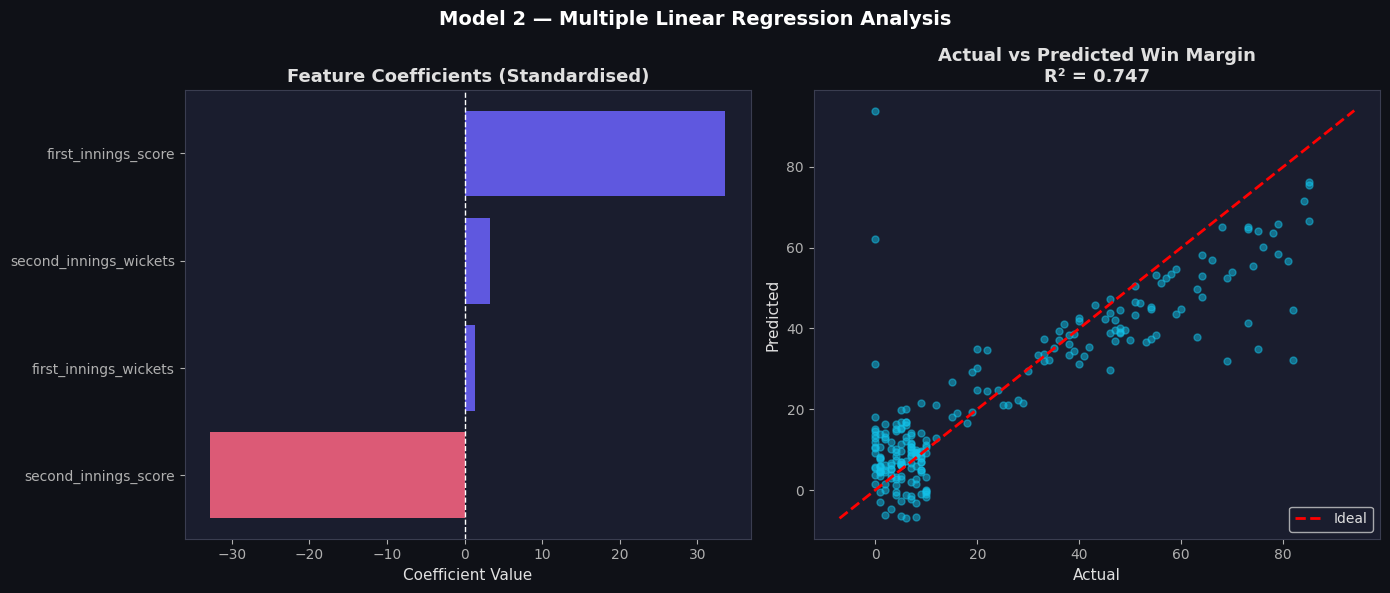

In [63]:
# Cell 18 — Model 2 Regression Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0f1117')
for ax in axes:
    ax.set_facecolor('#1a1d2e')

# Feature coefficients
coef_df = pd.Series(lr2.coef_, index=feat_cols).sort_values()
colors_c = [PALETTE[1] if v < 0 else PALETTE[0] for v in coef_df]
axes[0].barh(coef_df.index, coef_df.values, color=colors_c, alpha=0.85)
axes[0].axvline(0, color='white', lw=1, linestyle='--')
axes[0].set_title('Feature Coefficients (Standardised)', fontweight='bold')
axes[0].set_xlabel('Coefficient Value')

# Actual vs Predicted
axes[1].scatter(y2_te, y2_pred, alpha=0.5, color=PALETTE[4], s=25)
mn2, mx2 = min(y2_te.min(), y2_pred.min()), max(y2_te.max(), y2_pred.max())
axes[1].plot([mn2, mx2], [mn2, mx2], 'r--', lw=2, label='Ideal')
axes[1].set_title(f'Actual vs Predicted Win Margin\nR² = {r2_score(y2_te, y2_pred):.3f}',
                  fontweight='bold')
axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted')
axes[1].legend()

plt.suptitle('Model 2 — Multiple Linear Regression Analysis',
             fontsize=14, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

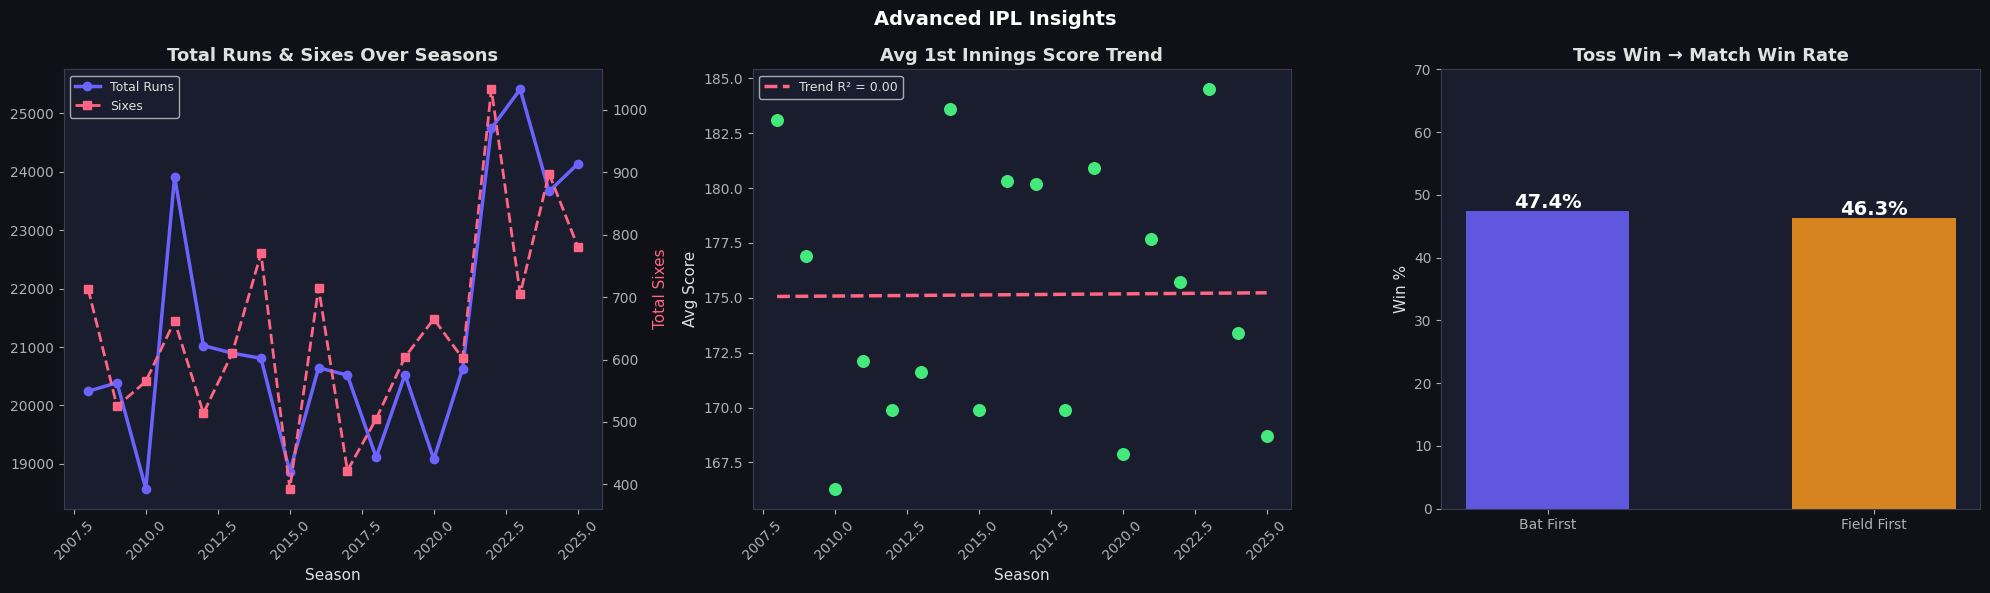

In [64]:
# Cell 19 — Advanced Insights
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('#0f1117')
for ax in axes:
    ax.set_facecolor('#1a1d2e')

sea = seasons.copy()

# Total runs & sixes per season
axes[0].plot(sea['season'], sea['total_runs_scored'], marker='o',
             color=PALETTE[0], lw=2.5, label='Total Runs')
ax2b = axes[0].twinx()
ax2b.plot(sea['season'], sea['total_sixes'], marker='s',
          color=PALETTE[1], lw=2, linestyle='--', label='Sixes')
ax2b.set_ylabel('Total Sixes', color=PALETTE[1])
lines1, lbl1 = axes[0].get_legend_handles_labels()
lines2, lbl2 = ax2b.get_legend_handles_labels()
axes[0].legend(lines1 + lines2, lbl1 + lbl2, fontsize=9)
axes[0].set_title('Total Runs & Sixes Over Seasons', fontweight='bold')
axes[0].set_xlabel('Season'); axes[0].tick_params(axis='x', rotation=45)

# Avg 1st innings score trend + regression line
x_sea = sea['season'].values.reshape(-1, 1)
y_sea = sea['avg_first_innings_score'].values
lr_sea = LinearRegression().fit(x_sea, y_sea)
axes[1].scatter(sea['season'], sea['avg_first_innings_score'],
                color=PALETTE[2], s=70, zorder=3)
axes[1].plot(sea['season'], lr_sea.predict(x_sea),
             color=PALETTE[1], lw=2.5, linestyle='--',
             label=f"Trend R² = {r2_score(y_sea, lr_sea.predict(x_sea)):.2f}")
axes[1].set_title('Avg 1st Innings Score Trend', fontweight='bold')
axes[1].set_xlabel('Season'); axes[1].set_ylabel('Avg Score')
axes[1].legend(fontsize=9); axes[1].tick_params(axis='x', rotation=45)

# Toss win → match win rate
bf_wins  = matches[(matches['toss_decision'] == 'bat') &
                   (matches['winner'] == matches['toss_winner'])].shape[0]
bf_total = matches[matches['toss_decision'] == 'bat'].shape[0]
ff_wins  = matches[(matches['toss_decision'] == 'field') &
                   (matches['winner'] == matches['toss_winner'])].shape[0]
ff_total = matches[matches['toss_decision'] == 'field'].shape[0]
cats = ['Bat First', 'Field First']
vals = [100 * bf_wins / bf_total, 100 * ff_wins / ff_total]
bars = axes[2].bar(cats, vals, color=[PALETTE[0], PALETTE[3]], alpha=0.85, width=0.5)
for bar, val in zip(bars, vals):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=14,
                 fontweight='bold', color='white')
axes[2].set_title('Toss Win → Match Win Rate', fontweight='bold')
axes[2].set_ylabel('Win %'); axes[2].set_ylim(0, 70)

plt.suptitle('Advanced IPL Insights', fontsize=14, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

In [65]:
# Cell 20 — Project Summary
summary = {
    "Metric": [
        "Total Matches", "Total Deliveries", "Total Players", "Seasons Covered",
        "Avg 1st Innings Score", "Avg 2nd Innings Score",
        "Pearson r (1st vs 2nd score)", "H1 p-value (bat-first vs chasing)",
        "H2 p-value (high score ~ win)", "Model 1 R²", "Model 2 R²"
    ],
    "Value": [
        f"{len(matches):,}", f"{len(deliveries):,}", f"{len(players):,}", f"{seasons['season'].nunique()}",
        f"{matches['first_innings_score'].mean():.2f}",
        f"{matches['second_innings_score'].mean():.2f}",
        f"{r_p:.4f}",
        f"{p1:.6f} → ✅ Reject H₀",
        f"{p2:.4f} → ✅ Reject H₀",
        f"{r2_score(y1_te, y1_pred):.4f}",
        f"{r2_score(y2_te, y2_pred):.4f}"
    ]
}
display(pd.DataFrame(summary))
print("\n🏏 IPL Analytics Project Complete!")

,Metric,Value
0,Total Matches,"1,158"
1,Total Deliveries,"134,190"
2,Total Players,580
3,Seasons Covered,18
4,Avg 1st Innings Score,175.10
5,Avg 2nd Innings Score,155.80
6,Pearson r (1st vs 2nd score),0.7994
7,H1 p-value (bat-first vs chasing),0.000000 → ✅ Reject H₀
8,H2 p-value (high score ~ win),0.0208 → ✅ Reject H₀
9,Model 1 R²,0.6559



🏏 IPL Analytics Project Complete!
